# Model Building

This notebook performs the predictive model building and testing for the Cardiovascular Disease Prediction project.

List of concepts to study: Encoding, pipelines, ColumnTransformer, random forest classifier and using it to choose best features, SelectFromModel/techniques for feature selection, the "right" ways to do feature selection to prevent data leakage, 

### Data Load and Preparation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)

plt.style.use('bmh')
%matplotlib inline
sns.set()

In [13]:
df = pd.read_csv("../data/cleaned_data.csv")
df.dtypes

age                           int64
gender                       object
height                        int64
weight                      float64
systolic blood pressure       int64
diastolic blood pressure      int64
cholesterol                  object
glucose                      object
smoking                      object
alcohol                      object
physical activity            object
disease                      object
bmi                         float64
weight status                object
dtype: object

## Encoding, Splitting, Rescaling

In [14]:
target = 'disease'
X = df.drop(columns = target)
y = df[target].map({"Yes": 1, "No": 0})

#Split into training, validation and testing sets, stratify = y makes sure disease proportion in y in all splits are equal to the original df

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 21)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state = 21)

Creating a X_valid set results in honest estimates.
or
Nested cross-validation setup:

Inner loop: feature-selection + hyperparameter search all inside each training fold.
Outer loop: evaluation on held-out fold that never touched selection or tuning.

You cannot select features on all of X_train, since later when you tune hyperparameters with cross validation, each validation fold has already influenced which features to keep it. Therefore the validation set is no longer unseen data.

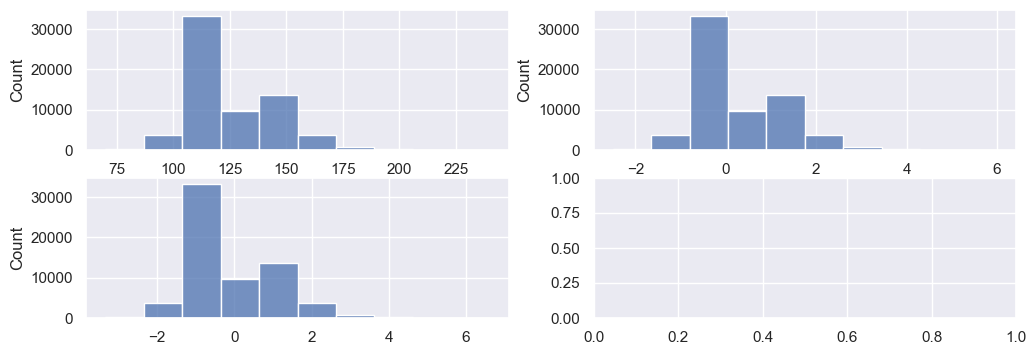

In [4]:
#StandardScaler vs RobustScaler

fig, ax = plt.subplots(2, 2, figsize = (12, 4))
sns.histplot(data = df, x = "systolic blood pressure", bins = 10, ax = ax[0,0])

robust_scaler = RobustScaler()
robust_scaler.fit(df[["systolic blood pressure"]])
robust_data = robust_scaler.transform(df[["systolic blood pressure"]])

sns.histplot(x = robust_data[:, 0], bins = 10, ax = ax[0,1])


standard_scaler = StandardScaler()
standard_scaler.fit(df[["systolic blood pressure"]])
standard_data = standard_scaler.transform(df[["systolic blood pressure"]])

sns.histplot(x = standard_data[:, 0], bins = 10, ax = ax[1,0])
plt.show()

In [5]:
num_cols = ["age", "height", "weight", "bmi", "systolic blood pressure", "diastolic blood pressure"]
ord_cols = ["cholesterol", "glucose", "weight status"]
ohe_cols = ["gender", "smoking", "alcohol", "physical activity"]

ord_encoder = OrdinalEncoder(categories = [["normal", "above normal", "well above normal"], ["normal", "above normal", "well above normal"],
                                           ["Underweight", "Healthy", "Overweight", "Obese"]])

**Ordinal encoding** converts categorical data to numerical values, preserving the order.

**One hot encoding** converts cateogrical data to a binary vector creating a new column for each category. Drops one column to avoid multicollinearity. 

Robust scaler because the data has outliers and robust scaler is more robust to outliers since it removes the median and scales by IQR.

In [6]:
preprocessor = ColumnTransformer([("num", RobustScaler(), num_cols), 
                                  ("ord", ord_encoder, ord_cols), 
                                  ("ohe", OneHotEncoder(), ohe_cols)])

In [7]:
#class balance
pos_rate = (y_train == 1).mean()
print(f"Positive class prevalence (train): {pos_rate:.3f}")

Positive class prevalence (train): 0.509


In [8]:
print(y_train)

56630    1
4014     1
35338    0
28313    1
54171    1
        ..
48774    1
46994    0
24657    0
41465    1
56621    0
Name: disease, Length: 41535, dtype: int64


Feature selection fit on X_train, then transform valid and test. Hyperparameter tuning on valid, then test on test.

In [9]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [10]:
#rf = RandomForestClassifier(n_estimators=3000, n_jobs=-1)

#sfm = SelectFromModel(estimator=rf)
#sfm.fit(X_params, y_temp)

In [11]:
#best_columns = sfm.get_support()
#best_columns_rf = X_params.loc[:, best_columns].columns.to_list()
#best_columns_rf